# 01 — Data Exploration

**Project:** Content-Conditioned Positional Encoding for Patch-Level Diffusion in Time Series Forecasting

This notebook covers:
1. Dataset statistics (timesteps, variates, missing values)
2. ETTh1 full time series with train / val / test split boundaries
3. Non-stationarity analysis (rolling mean & std showing regime shifts)
4. Patch structure visualization — how a context window is divided into tokens
5. Weather dataset overview
6. Distribution shift across splits — the core motivation for xCPE

> **Run from the project root.** All paths are relative to `group_project/`.

In [1]:
import os, sys

# ── Find project root (works wherever the notebook is opened from) ────────
# Walk upward until we find CLAUDE.md, which lives in the project root.
_search = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.exists(os.path.join(_search, "CLAUDE.md")):
        break
    _search = os.path.dirname(_search)
PROJECT_ROOT = _search
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.utils.config import load_config
from src.data.preprocess import split_dataset, normalize, apply_normalization
from src.data.dataset import TimeSeriesDataset

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('husl')

# ── Paths ──────────────────────────────────────────────────────────────────────
CONFIG_PATH  = 'configs/baseline_etth1.yaml'
ETTH1_PATH   = 'data/raw/data/raw/ETDataset/ETT-small/ETTh1.csv'
WEATHER_PATH = 'data/data/raw/weather/weather.csv'
SAVE_DIR     = 'results/logs'
os.makedirs(SAVE_DIR, exist_ok=True)

cfg = load_config(CONFIG_PATH)
print('Config loaded:', cfg.data.dataset, '| horizon:', cfg.data.horizon,
      '| patch_length:', cfg.data.patch_length)

Project root: c:\Masters\Coursework\Spring 26\Deep Learning\group_project
Config loaded: ETTh1 | horizon: 96 | patch_length: 16


## 1. Load Datasets & Print Statistics

In [2]:
def load_and_split(csv_path, dataset_name, train_split=0.6, val_split=0.2):
    """Load CSV, split by time, normalize using train stats."""
    df       = pd.read_csv(csv_path)
    date_col = df.columns[0]
    dates    = pd.to_datetime(df[date_col])
    df_vals  = df.drop(columns=[date_col])

    train_df, val_df, test_df = split_dataset(
        df_vals, dataset_name, train_split, val_split
    )
    train_arr, mean, std = normalize(train_df.values.astype(np.float32))
    val_arr  = apply_normalization(val_df.values.astype(np.float32),  mean, std)
    test_arr = apply_normalization(test_df.values.astype(np.float32), mean, std)

    n        = len(df_vals)
    train_end = int(n * train_split)
    val_end   = int(n * (train_split + val_split))

    return dict(
        raw_df=df_vals, dates=dates,
        train_arr=train_arr, val_arr=val_arr, test_arr=test_arr,
        mean=mean, std=std,
        columns=df_vals.columns.tolist(),
        train_end=train_end, val_end=val_end, n=n,
    )

# ── ETTh1 ──────────────────────────────────────────────────────────────────────
etth1 = load_and_split(ETTH1_PATH, 'ETTh1',
                       cfg.data.train_split, cfg.data.val_split)
te1, ve1 = etth1['train_end'], etth1['val_end']
print(f"ETTh1   total={etth1['n']:,}  train={te1:,}  "
      f"val={ve1-te1:,}  test={etth1['n']-ve1:,}")
print(f"        variates: {etth1['columns']}")

# ── Weather (70/10/20 split) ────────────────────────────────────────────────────
try:
    weather = load_and_split(WEATHER_PATH, 'Weather', 0.7, 0.1)
    te_w, ve_w = weather['train_end'], weather['val_end']
    print(f"\nWeather total={weather['n']:,}  train={te_w:,}  "
          f"val={ve_w-te_w:,}  test={weather['n']-ve_w:,}")
    print(f"        variates: {len(weather['columns'])} columns")
except FileNotFoundError:
    weather = None
    print("\nWeather CSV not found — skipping Weather cells.")

ETTh1   total=17,420  train=10,452  val=3,484  test=3,484
        variates: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

Weather total=52,696  train=36,887  val=5,269  test=10,540
        variates: 21 columns


In [3]:
# ── Summary statistics table ────────────────────────────────────────────────────
rows = []
for name, data, (ts, vs) in [
    ('ETTh1',   etth1,   (cfg.data.train_split, cfg.data.val_split)),
    ('Weather', weather, (0.7, 0.1)) if weather else ('Weather', None, (0.7, 0.1)),
]:
    if data is None:
        rows.append({'Dataset': name, 'Note': 'not available'})
        continue
    n        = data['n']
    te, ve   = data['train_end'], data['val_end']
    freq_hrs = (data['dates'].iloc[1] - data['dates'].iloc[0]).total_seconds() / 3600
    missing  = data['raw_df'].isnull().sum().sum()
    rows.append({
        'Dataset':      name,
        'Total steps':  f"{n:,}",
        'Variates':     len(data['columns']),
        'Freq (h)':     freq_hrs,
        'Train':        f"{te:,}",
        'Val':          f"{ve-te:,}",
        'Test':         f"{n-ve:,}",
        'Missing vals': int(missing),
    })

print(pd.DataFrame(rows).to_string(index=False))
print("\nNo missing values in either dataset — no imputation needed.")

Dataset Total steps  Variates  Freq (h)  Train   Val   Test  Missing vals
  ETTh1      17,420         7  1.000000 10,452 3,484  3,484             0
Weather      52,696        21  0.166667 36,887 5,269 10,540             0

No missing values in either dataset — no imputation needed.


## 2. ETTh1 — Full Time Series

ETTh1 records 7 electrical transformer measurements at hourly frequency from July 2016 to July 2018.  
Vertical dashed lines mark the **train → val** and **val → test** boundaries.

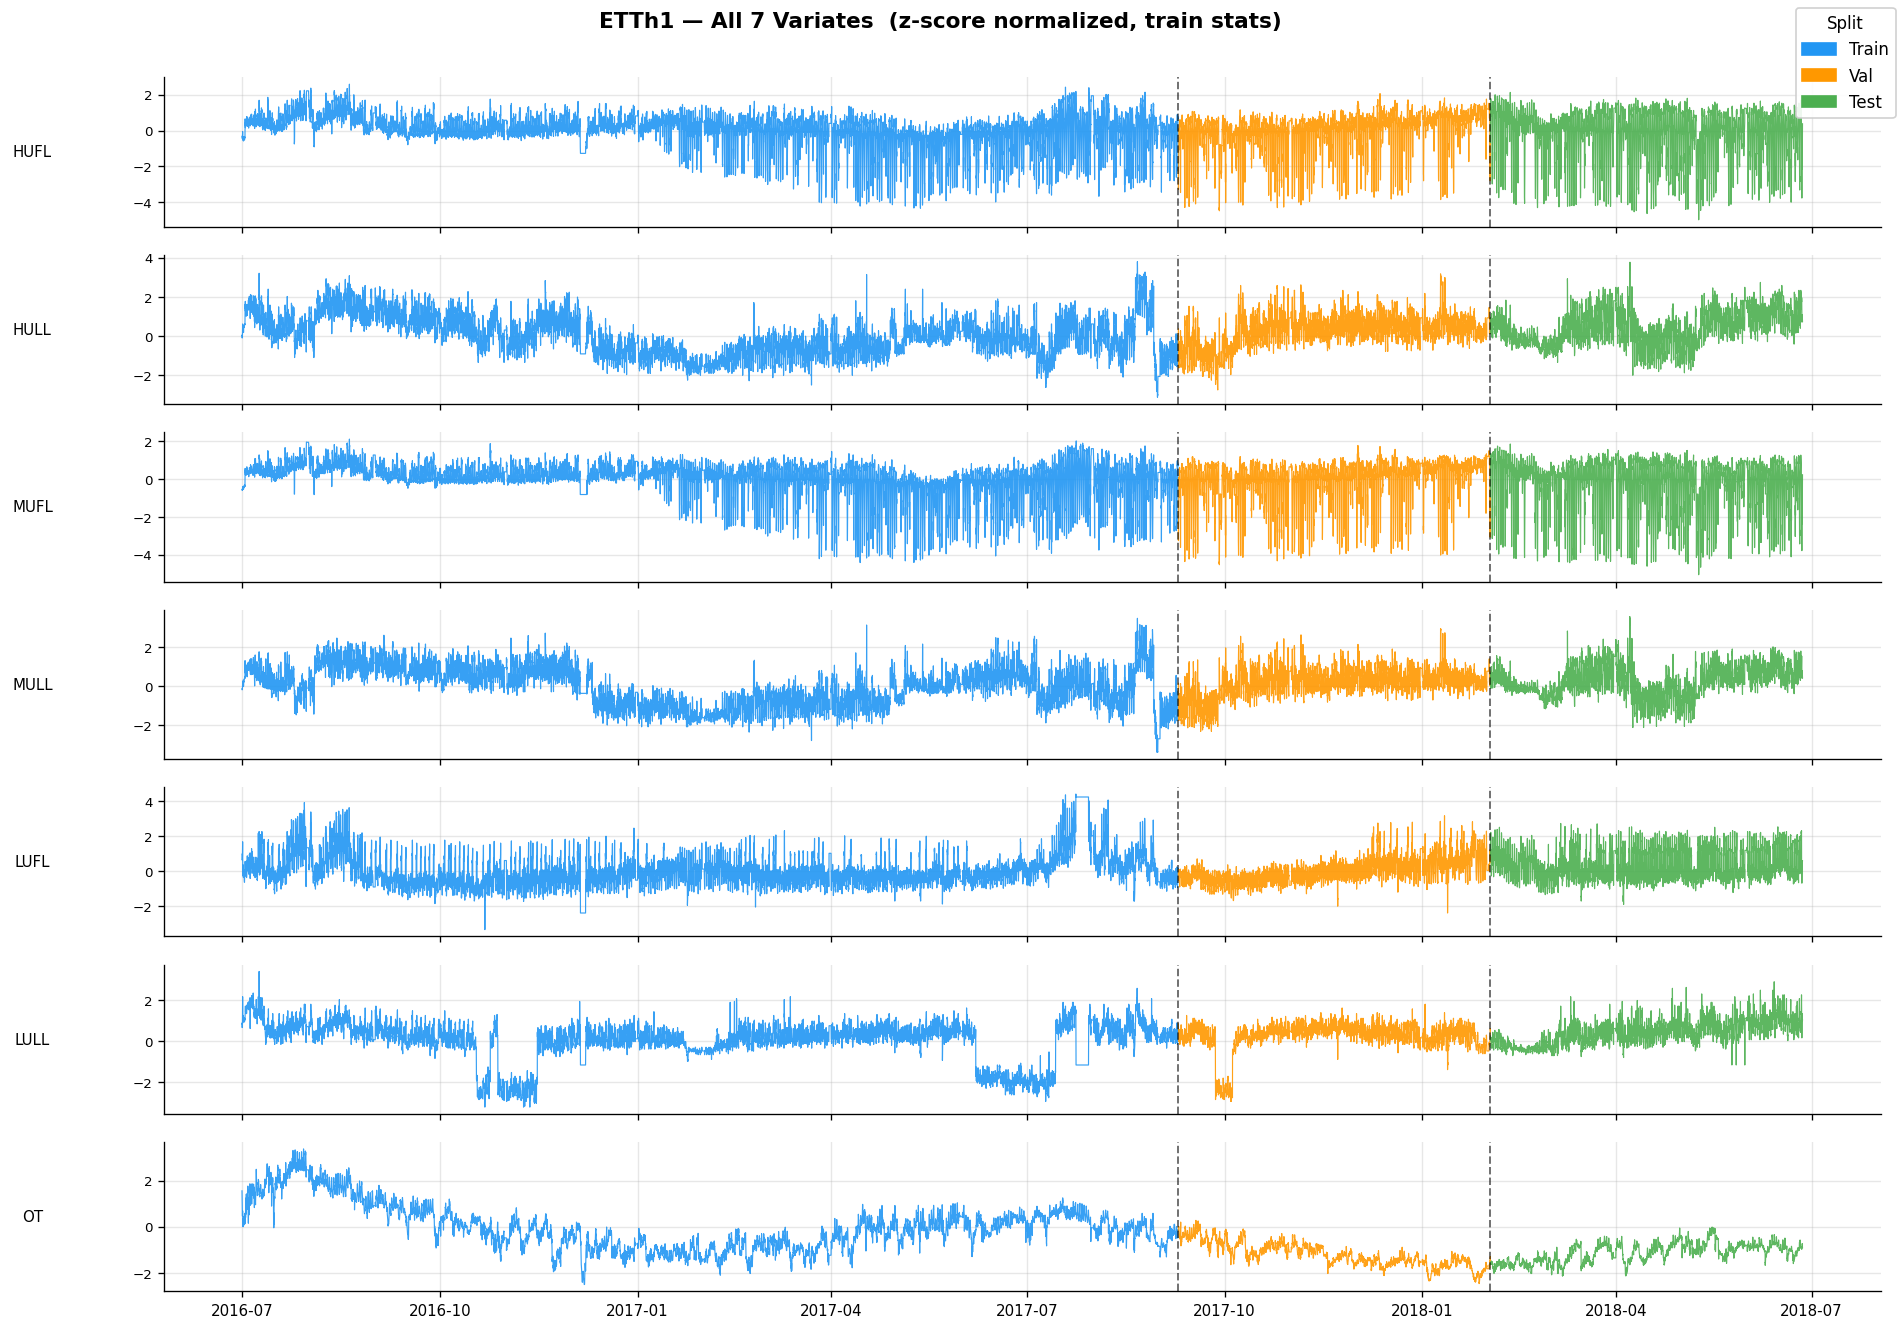

Saved → results/logs/etth1_full_series.png


In [4]:
all_arr1  = np.concatenate([etth1['train_arr'], etth1['val_arr'], etth1['test_arr']])
dates1    = etth1['dates'].values
cols1     = etth1['columns']
te1, ve1  = etth1['train_end'], etth1['val_end']

SPLIT_COLORS = {'Train': '#2196F3', 'Val': '#FF9800', 'Test': '#4CAF50'}

fig, axes = plt.subplots(len(cols1), 1, figsize=(16, 11), sharex=True)
fig.suptitle('ETTh1 — All 7 Variates  (z-score normalized, train stats)',
             fontsize=13, fontweight='bold', y=1.005)

for i, col in enumerate(cols1):
    ax = axes[i]
    ax.plot(dates1[:te1],       all_arr1[:te1, i],       color=SPLIT_COLORS['Train'], lw=0.7, alpha=0.9)
    ax.plot(dates1[te1:ve1],    all_arr1[te1:ve1, i],    color=SPLIT_COLORS['Val'],   lw=0.7, alpha=0.9)
    ax.plot(dates1[ve1:],       all_arr1[ve1:, i],       color=SPLIT_COLORS['Test'],  lw=0.7, alpha=0.9)
    ax.axvline(dates1[te1], color='black', lw=1.2, ls='--', alpha=0.55)
    ax.axvline(dates1[ve1], color='black', lw=1.2, ls='--', alpha=0.55)
    ax.set_ylabel(col, fontsize=9, rotation=0, labelpad=60, va='center')
    ax.tick_params(axis='y', labelsize=8)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in SPLIT_COLORS.items()]
fig.legend(handles=legend_patches, loc='upper right', fontsize=10, framealpha=0.9,
           title='Split', title_fontsize=10)
axes[-1].tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/etth1_full_series.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → results/logs/etth1_full_series.png")

## 3. Non-Stationarity in ETTh1

A rolling window (≈1 month) reveals that both the **mean** and **variance** of the OT (Oil Temperature) series shift substantially across the three splits.  
This is the core motivation for content-conditioned positional encoding: a fixed positional embedding assigns the same bias to position *i* regardless of which regime the series is in.

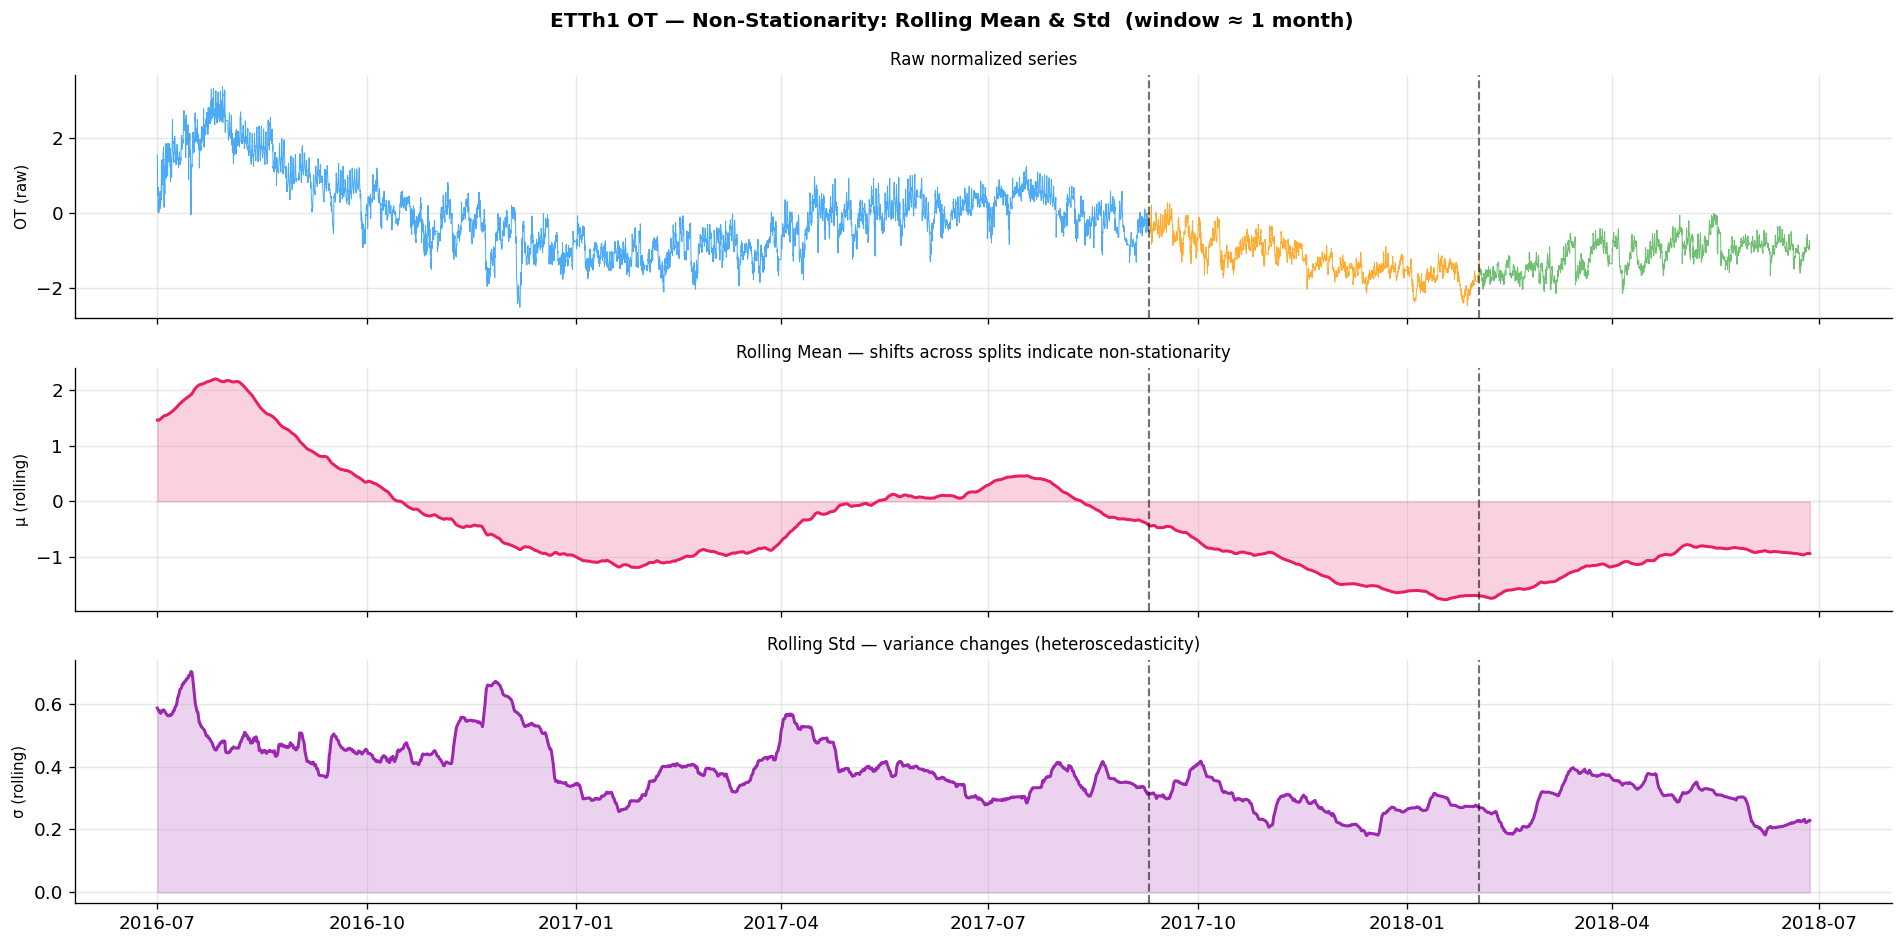

Saved → results/logs/etth1_nonstationarity.png

Key observation: rolling mean and std are NOT constant — the series is non-stationary.
xCPE can adapt to this by conditioning position on local content instead of absolute index.


In [5]:
col_ot  = cols1.index('OT')
ot_full = pd.Series(all_arr1[:, col_ot], index=pd.to_datetime(dates1))

window       = 24 * 30   # ~30-day rolling window (hourly data)
roll_mean    = ot_full.rolling(window, center=True, min_periods=1).mean()
roll_std     = ot_full.rolling(window, center=True, min_periods=1).std()

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
fig.suptitle('ETTh1 OT — Non-Stationarity: Rolling Mean & Std  (window ≈ 1 month)',
             fontsize=12, fontweight='bold')

# Raw series
ax = axes[0]
ax.plot(dates1[:te1],    all_arr1[:te1, col_ot],    color=SPLIT_COLORS['Train'], lw=0.6, alpha=0.8)
ax.plot(dates1[te1:ve1], all_arr1[te1:ve1, col_ot], color=SPLIT_COLORS['Val'],   lw=0.6, alpha=0.8)
ax.plot(dates1[ve1:],    all_arr1[ve1:, col_ot],    color=SPLIT_COLORS['Test'],  lw=0.6, alpha=0.8)
ax.set_ylabel('OT (raw)', fontsize=9)
ax.set_title('Raw normalized series', fontsize=10)

# Rolling mean
ax = axes[1]
ax.plot(dates1, roll_mean.values, color='#E91E63', lw=1.8)
ax.fill_between(dates1, roll_mean.values, alpha=0.2, color='#E91E63')
ax.set_ylabel('μ (rolling)', fontsize=9)
ax.set_title('Rolling Mean — shifts across splits indicate non-stationarity', fontsize=10)

# Rolling std
ax = axes[2]
ax.plot(dates1, roll_std.values, color='#9C27B0', lw=1.8)
ax.fill_between(dates1, roll_std.values, alpha=0.2, color='#9C27B0')
ax.set_ylabel('σ (rolling)', fontsize=9)
ax.set_title('Rolling Std — variance changes (heteroscedasticity)', fontsize=10)

for ax in axes:
    ax.axvline(dates1[te1], color='black', lw=1.3, ls='--', alpha=0.55)
    ax.axvline(dates1[ve1], color='black', lw=1.3, ls='--', alpha=0.55)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/etth1_nonstationarity.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → results/logs/etth1_nonstationarity.png")
print("\nKey observation: rolling mean and std are NOT constant — the series is non-stationary.")
print("xCPE can adapt to this by conditioning position on local content instead of absolute index.")

## 4. Patch Structure Visualization

Each sliding window of `context_length = 336` timesteps is divided into  
`336 // 16 = 21` non-overlapping **patch tokens** (each 16 timesteps long).  
The model forecasts the next `horizon = 96` timesteps from these 21 tokens.

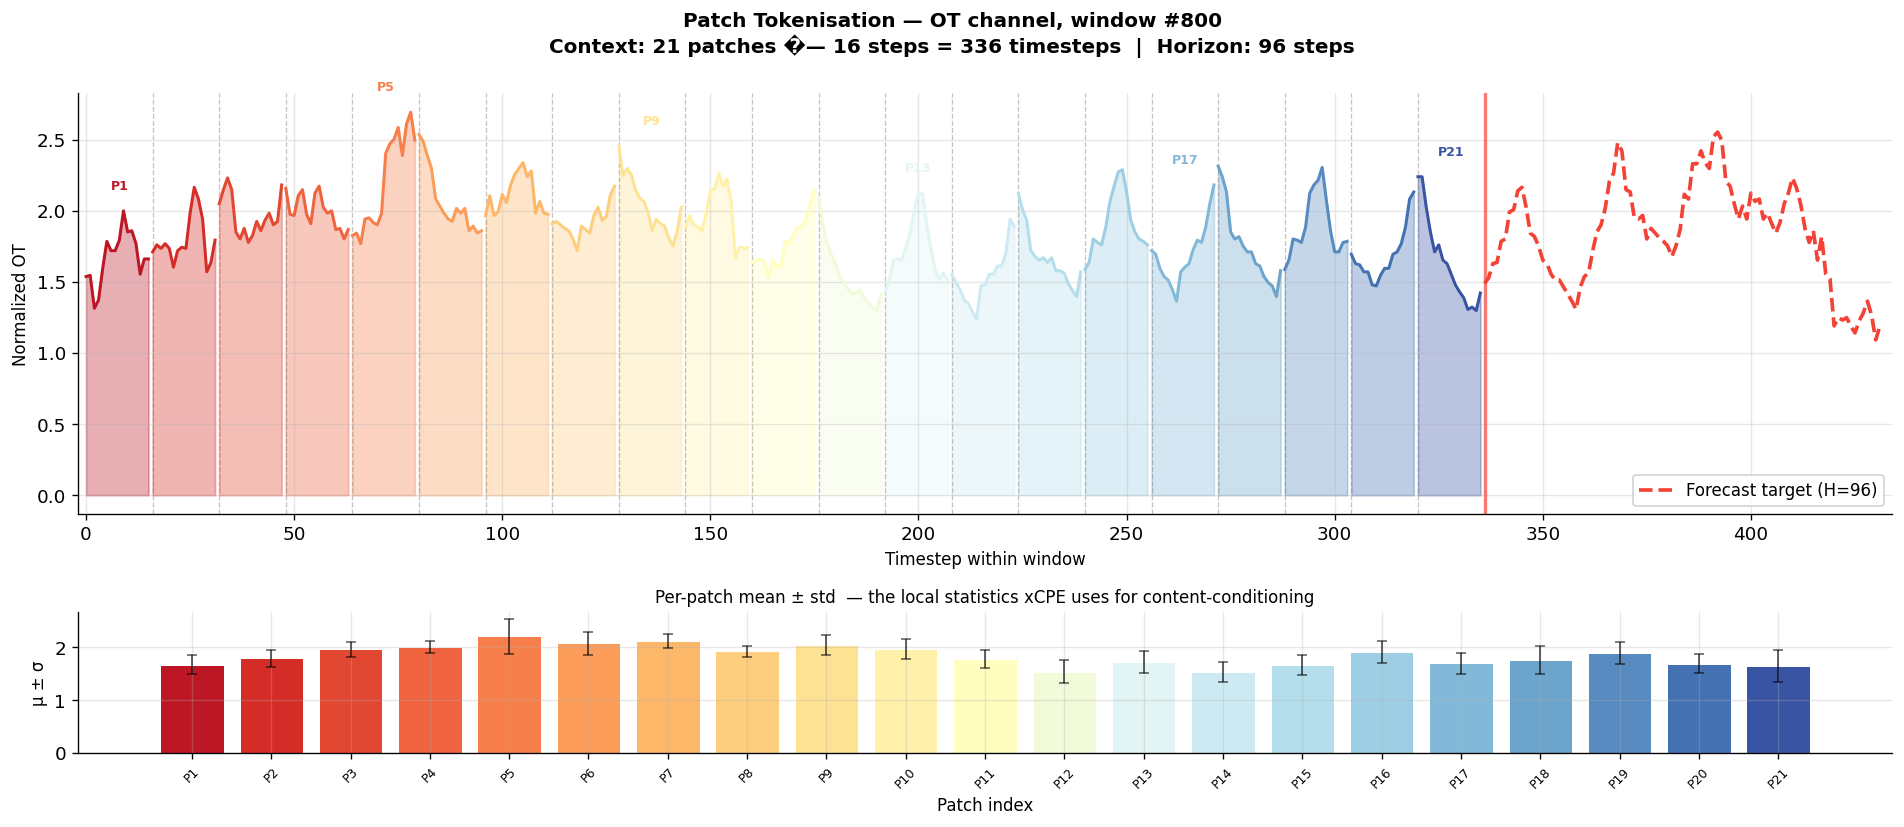

Saved → results/logs/patch_visualization.png

Each of the 21 coloured bars = one token fed to the Transformer.
xCPE computes positional embedding from [mean, var, slope] of the 3-token neighbourhood.


In [6]:
ds = TimeSeriesDataset(ETTH1_PATH, cfg.data, split='train')

# Use window #800 — a region with clear dynamics for illustration
WINDOW_IDX   = 800
patches, target = ds[WINDOW_IDX]
# patches: (21, 16, 7),  target: (96, 7)

ot_idx       = cols1.index('OT')
patch_vals   = patches[:, :, ot_idx].numpy()   # (21, 16)
target_vals  = target[:, ot_idx].numpy()        # (96,)
n_patches    = patch_vals.shape[0]              # 21
patch_len    = patch_vals.shape[1]              # 16

cmap         = plt.cm.RdYlBu
patch_colors = cmap(np.linspace(0.05, 0.95, n_patches))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 7),
    gridspec_kw={'height_ratios': [3, 1]}
)
fig.suptitle(
    f'Patch Tokenisation — OT channel, window #{WINDOW_IDX}\n'
    f'Context: {n_patches} patches �— {patch_len} steps = {n_patches*patch_len} timesteps  |  '
    f'Horizon: {len(target_vals)} steps',
    fontsize=12, fontweight='bold'
)

# ── Top: full context with coloured patches ───────────────────────────────────
context_flat = patch_vals.flatten()  # (336,)
for p in range(n_patches):
    s, e = p * patch_len, (p + 1) * patch_len
    xs   = np.arange(s, e)
    ax_top.fill_between(xs, context_flat[s:e], alpha=0.35, color=patch_colors[p])
    ax_top.plot(xs, context_flat[s:e], color=patch_colors[p], lw=1.8)
    if p < n_patches - 1:
        ax_top.axvline(e, color='gray', lw=0.8, ls='--', alpha=0.45)
    # Label every 4th patch
    if p % 4 == 0:
        ax_top.text(s + patch_len/2, context_flat[s:e].max() + 0.15,
                    f'P{p+1}', ha='center', fontsize=7.5, color=patch_colors[p],
                    fontweight='bold')

# Forecast horizon
L_ctx = len(context_flat)
xs_h  = np.arange(L_ctx, L_ctx + len(target_vals))
ax_top.plot(xs_h, target_vals, color='#F44336', lw=2.2, ls='--',
            label=f'Forecast target (H={len(target_vals)})')
ax_top.axvline(L_ctx, color='#F44336', lw=2, alpha=0.7)
ax_top.set_xlim(-2, L_ctx + len(target_vals) + 2)
ax_top.set_xlabel('Timestep within window', fontsize=10)
ax_top.set_ylabel('Normalized OT', fontsize=10)
ax_top.legend(fontsize=10, framealpha=0.85)

# ── Bottom: per-patch statistics ──────────────────────────────────────────────
patch_means = patch_vals.mean(axis=1)    # (21,)
patch_stds  = patch_vals.std(axis=1)     # (21,)
x_idx       = np.arange(n_patches)

bars = ax_bot.bar(x_idx, patch_means, color=patch_colors,
                  edgecolor='white', linewidth=0.6, label='Patch mean')
ax_bot.errorbar(x_idx, patch_means, yerr=patch_stds,
                fmt='none', color='black', capsize=3, lw=1.2, alpha=0.6)
ax_bot.set_xlabel('Patch index', fontsize=10)
ax_bot.set_ylabel('μ ± σ', fontsize=10)
ax_bot.set_title(
    'Per-patch mean ± std  — the local statistics xCPE uses for content-conditioning',
    fontsize=10
)
ax_bot.set_xticks(x_idx)
ax_bot.set_xticklabels([f'P{i+1}' for i in x_idx], fontsize=7.5, rotation=45)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/patch_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → results/logs/patch_visualization.png")
print(f"\nEach of the {n_patches} coloured bars = one token fed to the Transformer.")
print("xCPE computes positional embedding from [mean, var, slope] of the 3-token neighbourhood.")

## 5. Context Window — All 7 Variates

Same window as above, showing all 7 ETTh1 channels simultaneously.  
Each variate is processed **channel-independently** inside the model.

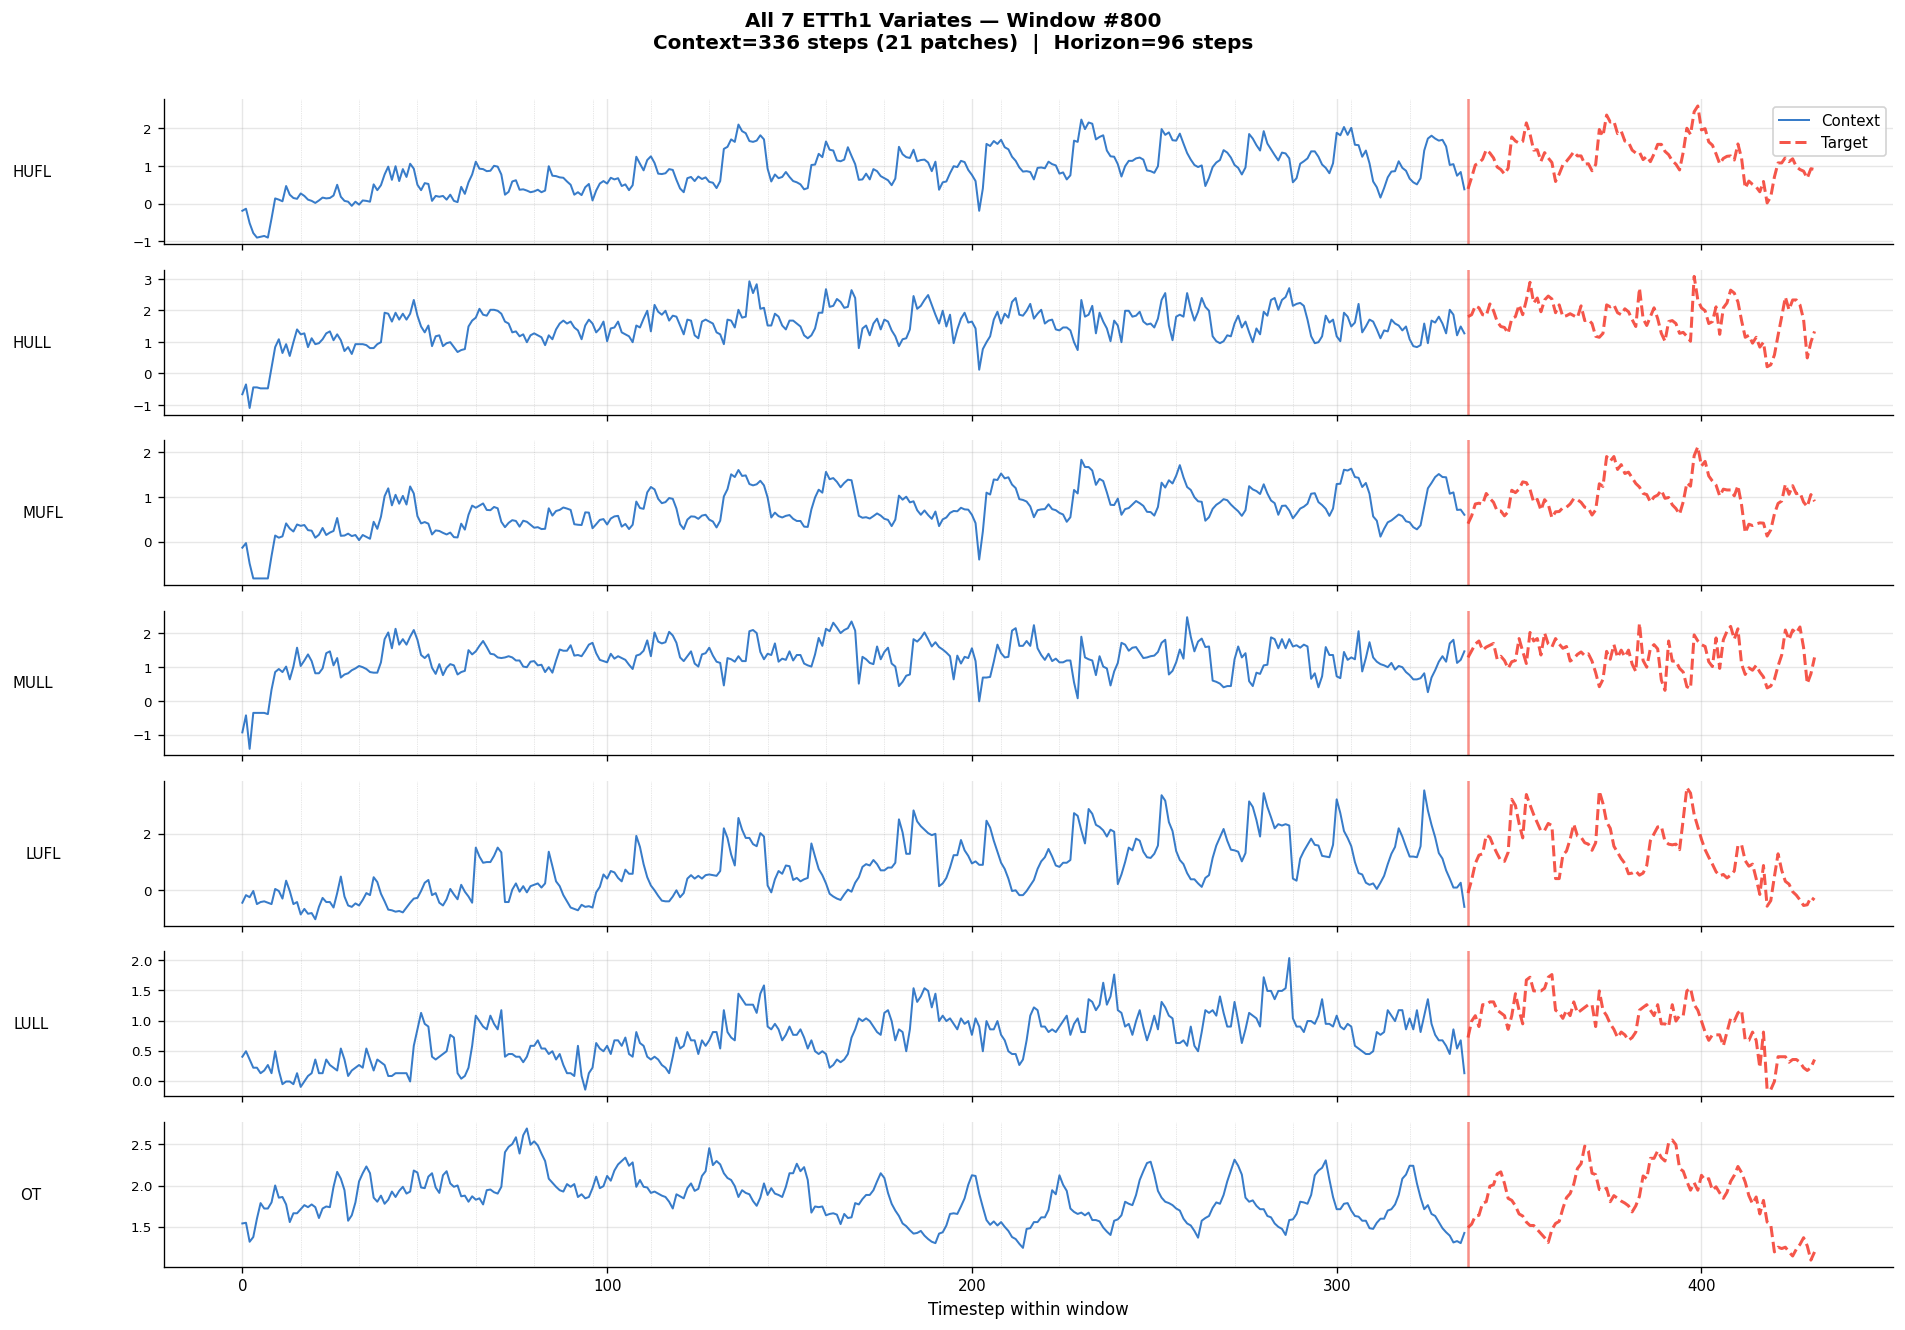

Saved → results/logs/all_variates_window.png


In [7]:
fig, axes = plt.subplots(len(cols1), 1, figsize=(16, 11), sharex=True)
fig.suptitle(
    f'All 7 ETTh1 Variates — Window #{WINDOW_IDX}\n'
    f'Context={n_patches * patch_len} steps ({n_patches} patches)  |  '
    f'Horizon={len(target_vals)} steps',
    fontsize=12, fontweight='bold', y=1.005
)

for i, col in enumerate(cols1):
    ax   = axes[i]
    ctx  = patches[:, :, i].numpy().flatten()   # (336,)
    tgt  = target[:, i].numpy()                  # (96,)

    ax.plot(np.arange(len(ctx)), ctx,
            color='#1565C0', lw=1.2, alpha=0.85, label='Context')
    ax.plot(np.arange(len(ctx), len(ctx) + len(tgt)), tgt,
            color='#F44336', lw=1.8, ls='--', alpha=0.9, label='Target')
    ax.axvline(len(ctx), color='#F44336', lw=1.5, alpha=0.6)

    # Light patch-boundary grid
    for p in range(1, n_patches):
        ax.axvline(p * patch_len, color='gray', lw=0.4, ls=':', alpha=0.4)

    ax.set_ylabel(col, fontsize=9, rotation=0, labelpad=60, va='center')
    ax.tick_params(axis='y', labelsize=8)

axes[0].legend(fontsize=9, framealpha=0.85, loc='upper right')
axes[-1].set_xlabel('Timestep within window', fontsize=10)
axes[-1].tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/all_variates_window.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → results/logs/all_variates_window.png")

## 6. Weather Dataset Overview

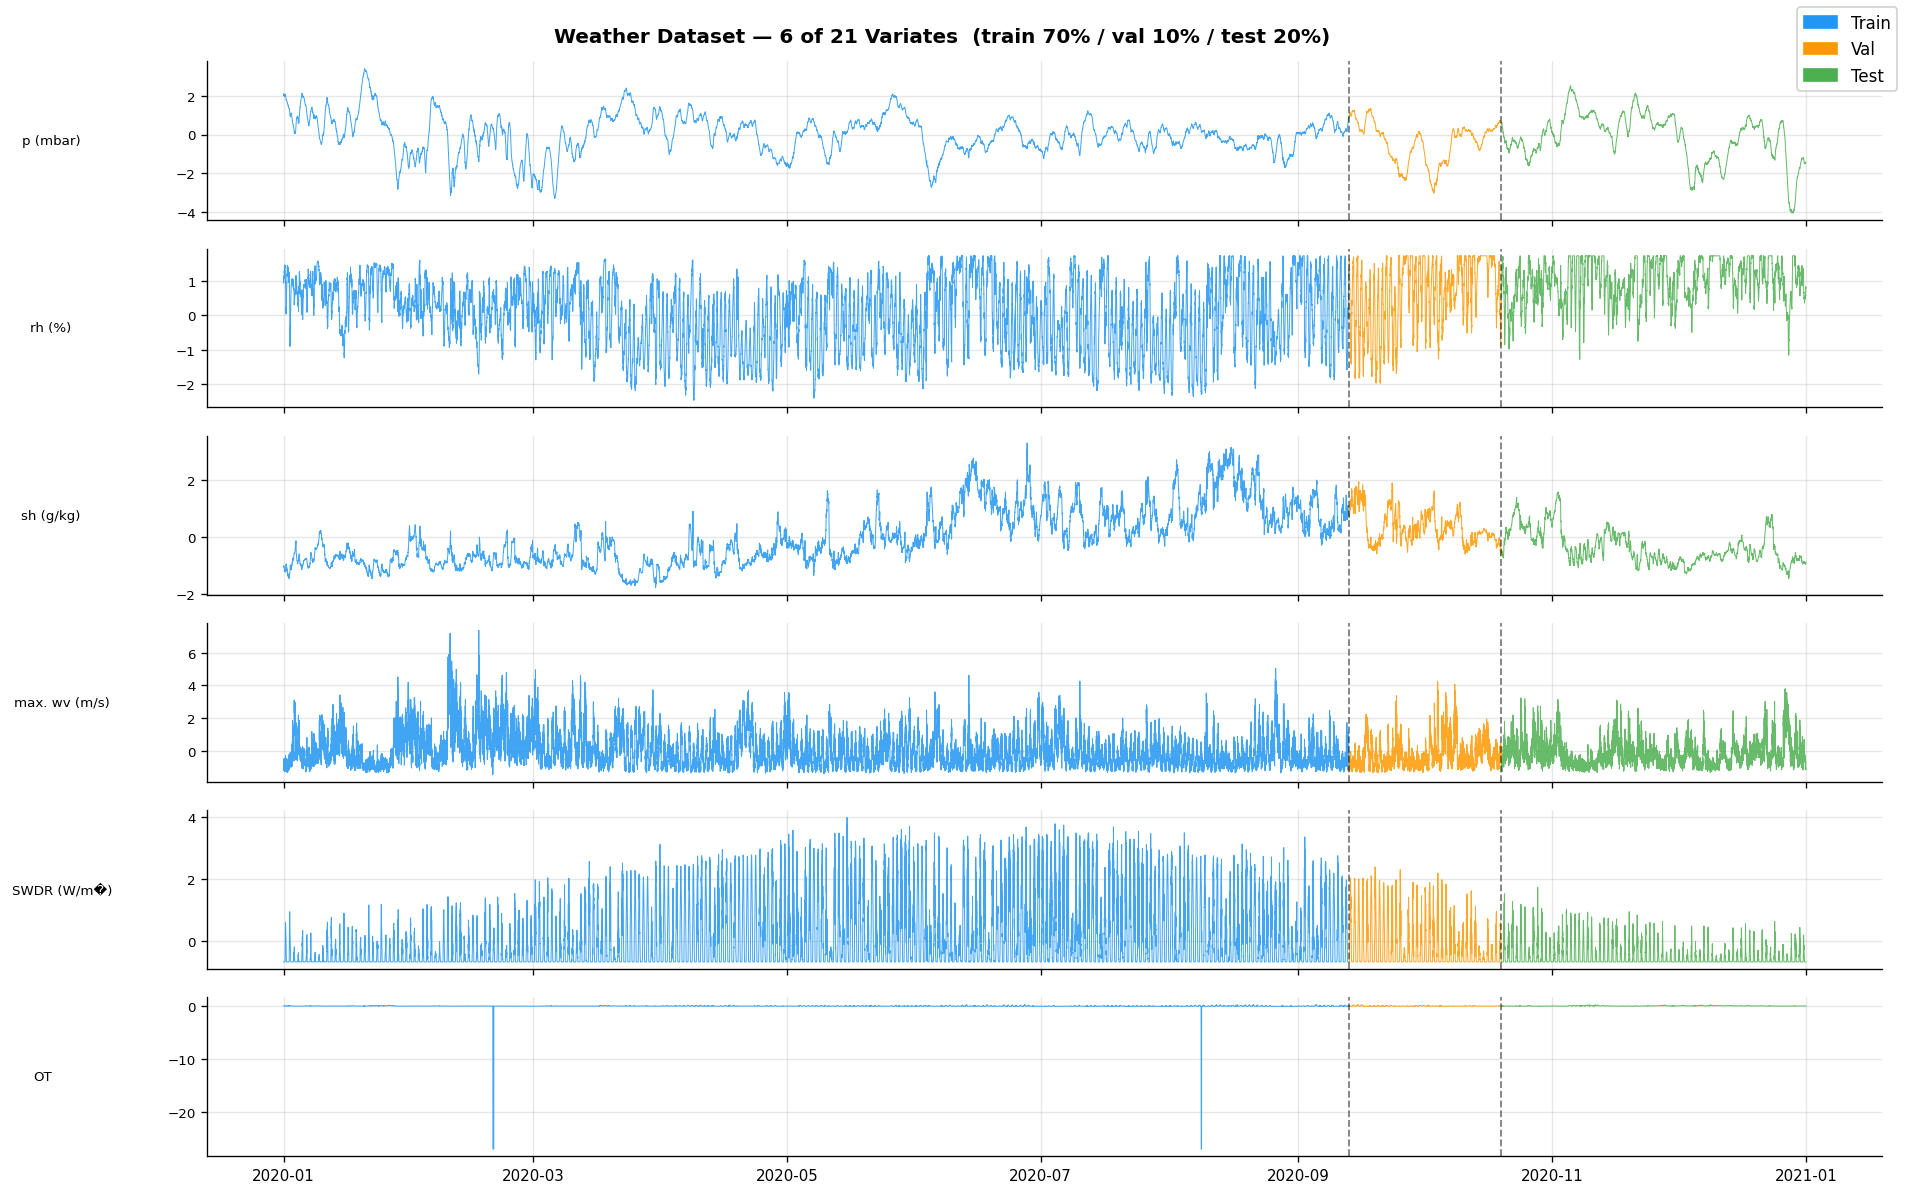

Saved → results/logs/weather_overview.png


In [8]:
if weather is None:
    print("Weather dataset not available — skipping this cell.")
else:
    all_w   = np.concatenate([weather['train_arr'], weather['val_arr'], weather['test_arr']])
    dates_w = weather['dates'].values
    cols_w  = weather['columns']
    te_w, ve_w = weather['train_end'], weather['val_end']

    # Show a representative subset of 6 variates
    sample_indices = np.linspace(0, len(cols_w) - 1, 6, dtype=int)
    sample_cols    = [cols_w[i] for i in sample_indices]

    fig, axes = plt.subplots(len(sample_cols), 1, figsize=(16, 10), sharex=True)
    fig.suptitle(
        f'Weather Dataset — 6 of {len(cols_w)} Variates  '
        f'(train 70% / val 10% / test 20%)',
        fontsize=12, fontweight='bold'
    )

    for ax, col in zip(axes, sample_cols):
        ci = cols_w.index(col)
        ax.plot(dates_w[:te_w],       all_w[:te_w, ci],       color=SPLIT_COLORS['Train'], lw=0.6, alpha=0.85)
        ax.plot(dates_w[te_w:ve_w],   all_w[te_w:ve_w, ci],   color=SPLIT_COLORS['Val'],   lw=0.6, alpha=0.85)
        ax.plot(dates_w[ve_w:],       all_w[ve_w:, ci],       color=SPLIT_COLORS['Test'],  lw=0.6, alpha=0.85)
        ax.axvline(dates_w[te_w], color='black', lw=1.1, ls='--', alpha=0.5)
        ax.axvline(dates_w[ve_w], color='black', lw=1.1, ls='--', alpha=0.5)
        ax.set_ylabel(col[:14], fontsize=8, rotation=0, labelpad=75, va='center')
        ax.tick_params(axis='y', labelsize=8)

    legend_patches = [mpatches.Patch(color=c, label=l) for l, c in SPLIT_COLORS.items()]
    fig.legend(handles=legend_patches, loc='upper right', fontsize=10, framealpha=0.9)
    axes[-1].tick_params(axis='x', labelsize=9)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/weather_overview.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved → results/logs/weather_overview.png")

## 7. Distribution Shift Across Splits

If the distribution of values were identical across train / val / test, a model that memorised the training distribution would generalise perfectly.  
The histograms below show that this is **not** the case — a direct argument for why models need to encode *content* rather than just position.

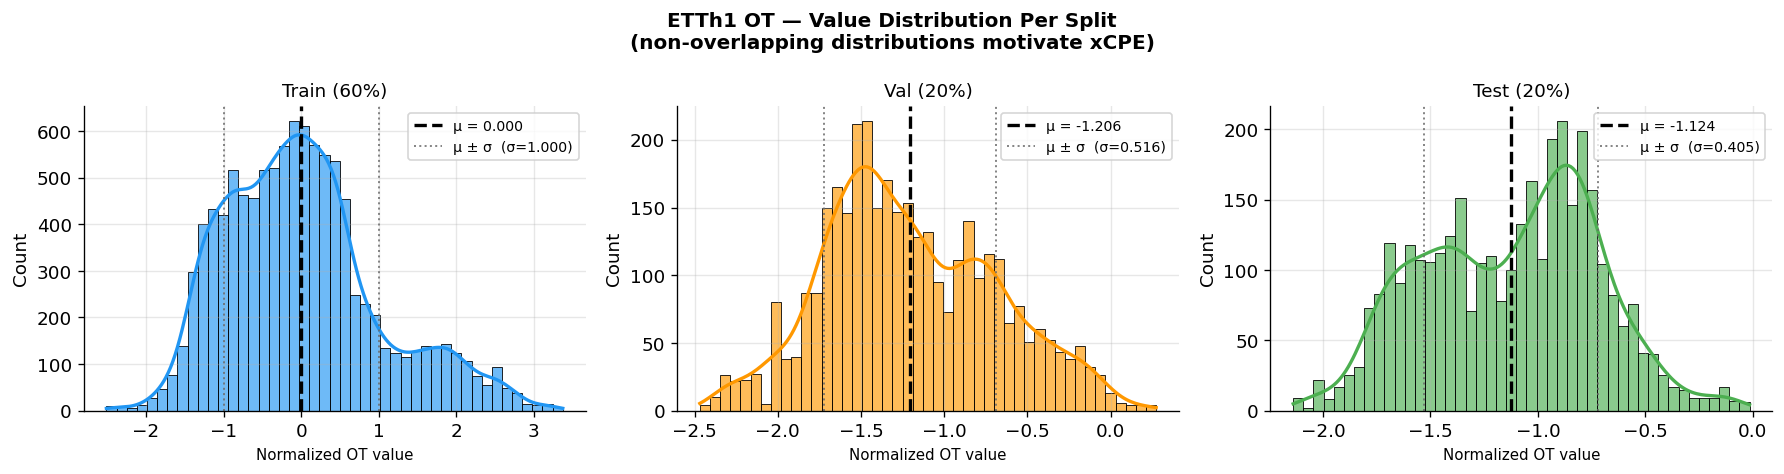

Saved → results/logs/distribution_shift.png
Train (60%)         μ=+0.0000  σ=1.0000  Δμ from train = +0.0000
Val (20%)           μ=-1.2061  σ=0.5160  Δμ from train = -1.2061
Test (20%)          μ=-1.1242  σ=0.4048  Δμ from train = -1.1242


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(
    'ETTh1 OT — Value Distribution Per Split\n'
    '(non-overlapping distributions motivate xCPE)',
    fontsize=12, fontweight='bold'
)

split_data = [
    ('Train (60%)', etth1['train_arr'][:, col_ot], SPLIT_COLORS['Train']),
    ('Val (20%)',   etth1['val_arr'][:,   col_ot], SPLIT_COLORS['Val']),
    ('Test (20%)',  etth1['test_arr'][:,  col_ot], SPLIT_COLORS['Test']),
]

for ax, (name, data, color) in zip(axes, split_data):
    sns.histplot(data, bins=45, color=color, alpha=0.65, kde=True,
                 line_kws={'lw': 2}, ax=ax)
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu,             color='black',  lw=2,   ls='--', label=f'μ = {mu:.3f}')
    ax.axvline(mu + sigma,     color='dimgray', lw=1.2, ls=':',  alpha=0.8)
    ax.axvline(mu - sigma,     color='dimgray', lw=1.2, ls=':',  alpha=0.8,
               label=f'μ ± σ  (σ={sigma:.3f})')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Normalized OT value', fontsize=9)
    ax.legend(fontsize=8.5, framealpha=0.8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/distribution_shift.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → results/logs/distribution_shift.png")

# Print shift magnitudes
train_mu = etth1['train_arr'][:, col_ot].mean()
for name, data, _ in split_data:
    print(f"{name:<18}  μ={data.mean():+.4f}  σ={data.std():.4f}  "
          f"Δμ from train = {data.mean()-train_mu:+.4f}")

## 8. Autocorrelation — Seasonal Patterns

Strong autocorrelation at lags = 24 h and 168 h (7 days) confirms daily and weekly seasonality.  
This periodicity is another reason why **content-based** positional encoding could outperform fixed sinusoidal: two patches from the same phase of different cycles look similar and should receive similar positional embeddings.

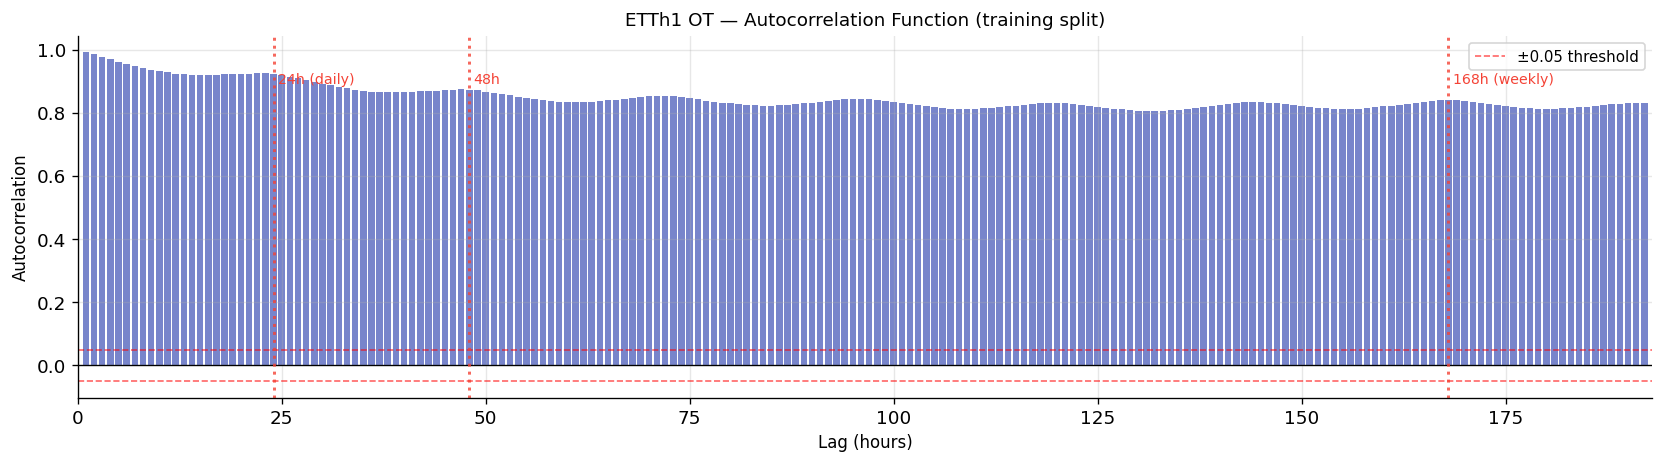

Saved → results/logs/etth1_autocorrelation.png

Peak at lag=24: ACF = 0.923
Peak at lag=168: ACF = 0.840


In [10]:
from pandas.plotting import autocorrelation_plot

ot_train = pd.Series(etth1['train_arr'][:, col_ot])
max_lag  = 24 * 8   # 8 days

# Compute autocorrelation manually for control over lag range
acf_vals = [ot_train.autocorr(lag=l) for l in range(1, max_lag + 1)]
lags     = np.arange(1, max_lag + 1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(lags, acf_vals, color='#3F51B5', alpha=0.7, width=0.8)
ax.axhline(0,   color='black', lw=0.8)
ax.axhline( 0.05, color='red', lw=1, ls='--', alpha=0.6, label='±0.05 threshold')
ax.axhline(-0.05, color='red', lw=1, ls='--', alpha=0.6)

# Annotate daily and weekly peaks
for lag, label in [(24, '24h (daily)'), (48, '48h'), (168, '168h (weekly)')]:
    if lag <= max_lag:
        ax.axvline(lag, color='#F44336', lw=1.8, ls=':', alpha=0.8)
        ax.text(lag + 0.5, max(acf_vals) * 0.9, label, fontsize=8.5, color='#F44336')

ax.set_xlabel('Lag (hours)', fontsize=10)
ax.set_ylabel('Autocorrelation', fontsize=10)
ax.set_title('ETTh1 OT — Autocorrelation Function (training split)', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, max_lag + 1)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/etth1_autocorrelation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → results/logs/etth1_autocorrelation.png")
print(f"\nPeak at lag=24: ACF = {acf_vals[23]:.3f}")
if max_lag >= 168:
    print(f"Peak at lag=168: ACF = {acf_vals[167]:.3f}")

## 9. Summary

| Finding | Implication for xCPE |
|---|---|
| Rolling mean shifts across splits | Fixed absolute PE encodes position regardless of regime — xCPE adapts |
| Rolling std (variance) is non-constant | Content-based encoding captures local volatility via the `var` statistic |
| Distribution of OT differs across train / val / test | Model must generalise to unseen regimes — PE flexibility matters |
| Strong 24h / 168h autocorrelation | Patches from the same seasonal phase have similar neighbourhoods → xCPE clusters them |
| No missing values in either dataset | No imputation needed; pipeline is clean |

**Next:** `02_positional_encoding_viz.ipynb` — compare the embedding matrices produced by `FixedPositionalEmbedding` vs `xCPE` on this data.